# Integrated Probability Analysis

## Student Performance Dataset

This project performs probability analysis using an AI-generated rough student dataset.

### Dataset Variables

- Student_ID
- study_hours
- attendance
- group_discussion
- previous_test_score
- final_exam_pass

### Objectives

1. Understand the basics of probability.
2. Calculate empirical and theoretical probability.
3. Create a random variable and probability distribution.
4. Create a Venn diagram.
5. Create a contingency table.
6. Understand relationships between events.
7. Apply Bayes' Theorem.

## Import Required Librarie

In [61]:
import pandas as pd


## Load Dataset

In [62]:
df = pd.read_csv(r"C:\Users\DDR\Downloads\Expectation Decider Dataset.csv")

df.head()

,Student_ID,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,STU1005,7.2,100.0,Yes,85.0,Fail
1,STU1118,8.2,75.3,Yes,74.2,Pass
2,STU1113,6.6,74.5,No,65.5,Fail
3,STU1105,9.4,91.4,Yes,76.3,Fail
4,STU1032,1.0,82.0,Yes,55.1,Fail


## Dataset Information

In [63]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

df.info()

Number of Rows: 120
Number of Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           120 non-null    str    
 1   study_hours          120 non-null    float64
 2   attendance           120 non-null    float64
 3   group_discussion     120 non-null    str    
 4   previous_test_score  120 non-null    float64
 5   final_exam_pass      120 non-null    str    
dtypes: float64(3), str(3)
memory usage: 7.3 KB


# 1. Understanding the Basics of Probability

Probability is the measure of how likely an event is to occur.

The value of probability ranges from 0 to 1.

### Key Probability Terminology

- **Experiment:** A process that produces an outcome.
- **Outcome:** The result of an experiment.
- **Event:** A specific outcome or group of outcomes.
- **Sample Space:** The set of all possible outcomes.
- **Joint Probability:** Probability that two events occur together.
- **Marginal Probability:** Probability of a single event.
- **Conditional Probability:** Probability of one event given that another event has occurred.

### Probability Events from the Dataset

1. A student passes the final exam.
2. A student participates in group discussion.
3. A student has attendance above 80%.


In [64]:
# Total number of students
total_students = len(df)

# Number of students who passed
pass_students = (df["final_exam_pass"] == "Pass").sum()

# Number of students who participated in group discussion
group_students = (df["group_discussion"] == "Yes").sum()

# Number of students with attendance above 80%
high_attendance = (df["attendance"] > 80).sum()

print("Total Students:", total_students)
print("Students who Passed:", pass_students)
print("Students in Group Discussion:", group_students)
print("Students with Attendance > 80%:", high_attendance)


Total Students: 120
Students who Passed: 79
Students in Group Discussion: 72
Students with Attendance > 80%: 46


# 2. Types of Events

## Empirical Probability

Empirical probability is calculated from the actual observations in the dataset.

Formula:

P(Event) = Number of favorable outcomes / Total number of outcomes

In this analysis, we calculate the probability that a randomly selected student passes the final exam.

## Theoretical Probability

Theoretical probability is calculated using a mathematical probability model.

For 3 randomly selected students, we use the Binomial Distribution to calculate the probability that exactly 2 students pass the final exam.

In [65]:
total_students = len(df)
pass_students = (df["final_exam_pass"] == "Pass").sum()

p_pass = pass_students / total_students

print("Total Students:", total_students)
print("Students Passed:", pass_students)
print("Empirical Probability of Passing:", round(p_pass, 4))
print("Percentage:", round(p_pass * 100, 2), "%")

Total Students: 120
Students Passed: 79
Empirical Probability of Passing: 0.6583
Percentage: 65.83 %


In [66]:
# Theoretical probability using Binomial Distribution

import math

n = 3
p = p_pass
q = 1 - p
k = 2

probability_2_pass = math.comb(n, k) * (p ** k) * (q ** (n-k))

print("Probability that exactly 2 out of 3 students pass:")
print(round(probability_2_pass, 4))
print("Percentage:", round(probability_2_pass * 100, 2), "%")

Probability that exactly 2 out of 3 students pass:
0.4442
Percentage: 44.42 %


### Interpretation

The empirical probability is based on the actual student data.

The theoretical probability uses the Binomial Distribution and assumes that each selected student's pass probability is the same as the observed pass probability.

# 3. Random Variable & Probability Distribution

Let X be the number of students who pass the final exam out of 3 randomly selected students.

Therefore, X can take the values:

X = 0, 1, 2, 3

We use the Binomial Distribution formula:

P(X = k) = C(n,k) × p^k × (1-p)^(n-k)

Where:

- n = 3 students
- p = Probability of passing
- k = Number of students passing
- (1-p) = Probability of failing

In [67]:
# Probability distribution for X = number of students passing out of 3

n = 3
p = p_pass
q = 1 - p

distribution = []

for k in range(4):
    probability = math.comb(n, k) * (p ** k) * (q ** (n-k))
    distribution.append([k, probability])

probability_table = pd.DataFrame(
    distribution,
    columns=["Number of Students Passing (X)", "Probability"]
)

probability_table["Percentage"] = (
    probability_table["Probability"] * 100
).round(2)

probability_table

,Number of Students Passing (X),Probability,Percentage
0,0,0.039885,3.99
1,1,0.230554,23.06
2,2,0.444238,44.42
3,3,0.285323,28.53


## Mean of the Random Variable

For a Binomial Distribution:

Mean = n × p

The mean represents the expected number of students who will pass out of 3 randomly selected students.

In [68]:
mean = n * p

print("Mean =", round(mean, 4))

Mean = 1.975


## Variance of the Random Variable

For a Binomial Distribution:

Variance = n × p × (1-p)

In [69]:
variance = n * p * q

print("Variance =", round(variance, 4))

Variance = 0.6748


### Interpretation

The probability distribution shows the probability of 0, 1, 2, or 3 students passing out of 3 randomly selected students.

The mean represents the expected number of students passing.

The variance represents how much the number of passing students can vary around the mean.

# 4. Venn Diagram in Probability

We define two events:

### Event A
Students who study more than 10 hours per week.

### Event B
Students who attend more than 80% of classes.

The overlapping region represents students who satisfy both conditions.

In [70]:
A = df["study_hours"] > 10
B = df["attendance"] > 80

# Calculate counts
A_count = A.sum()
B_count = B.sum()
both = (A & B).sum()

A_only = A_count - both
B_only = B_count - both
neither = len(df) - (A_count + B_count - both)

print("Students studying >10 hours:", A_count)
print("Students with attendance >80%:", B_count)
print("Students satisfying both conditions:", both)
print("Study >10 hours only:", A_only)
print("Attendance >80% only:", B_only)
print("Neither condition:", neither)

Students studying >10 hours: 56
Students with attendance >80%: 46
Students satisfying both conditions: 24
Study >10 hours only: 32
Attendance >80% only: 22
Neither condition: 42


## Venn Diagram
Venn diagram shows the relationship between study hours and attendance.

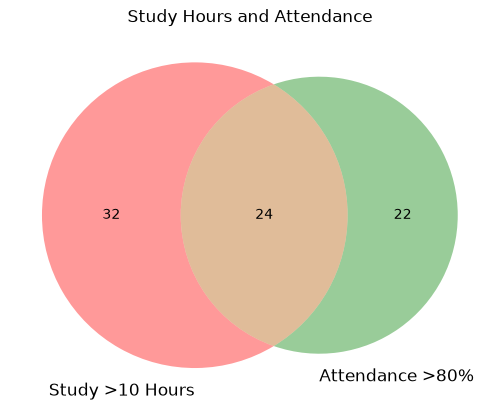

In [71]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Study more than 10 hours
a = len(df[df["study_hours"] > 10])

# Attendance more than 80%
b = len(df[df["attendance"] > 80])

# Both conditions
c = len(df[
    (df["study_hours"] > 10) &
    (df["attendance"] > 80)
])

# Only study hours
study_only = a - c

# Only attendance
attendance_only = b - c

venn2(
    subsets=(study_only, attendance_only, c),
    set_labels=("Study >10 Hours", "Attendance >80%")
)

plt.title("Study Hours and Attendance")
plt.show()

### Interpretation

The Venn diagram shows students who study more than 10 hours,
students with attendance above 80%, and students who satisfy both conditions.

# 4. Contingency Table & Probability Calculations
A contingency table shows the relationship between two categorical variables.

Here we compare:
- Group Discussion: Yes / No
- Final Exam: Pass / Fail

We will calculate:
1. Joint Probability
2. Marginal Probability
3. Conditional Probability

In [72]:
# Contingency Table

table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"],
    margins=True,normalize="all"
)

table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.150000,0.250000,0.4
Yes,0.191667,0.408333,0.6
All,0.341667,0.658333,1.0


## Joint Probability

Joint probability means the probability that both events happen together.

Here:

P(Group Discussion AND Pass)

In [73]:
# Joint Probability

total = len(df)

both_pass = len(
    df[
        (df["group_discussion"] == "Yes") &
        (df["final_exam_pass"] == "Pass")
    ]
)

joint_probability = both_pass / total

print("Joint Probability =", round(joint_probability, 4))
print("Percentage =", round(joint_probability * 100, 2), "%")

Joint Probability = 0.4083
Percentage = 40.83 %


## Marginal Probability

Marginal probability means the probability of one event without considering another event.

Here:

P(Pass)

In [74]:
# Marginal Probability

pass_students = len(
    df[df["final_exam_pass"] == "Pass"]
)

marginal_probability = pass_students / total

print("Marginal Probability of Pass =", round(marginal_probability, 4))
print("Percentage =", round(marginal_probability * 100, 2), "%")

Marginal Probability of Pass = 0.6583
Percentage = 65.83 %


## Conditional Probability

Conditional probability tells us the probability of passing the exam when the student participated in group discussion.

Formula:

P(Pass | Group Discussion)
=
P(Group Discussion AND Pass) / P(Group Discussion)

In [75]:
# Conditional Probability

group_students = len(
    df[df["group_discussion"] == "Yes"]
)

conditional_probability = both_pass / group_students

print(
    "P(Pass | Group Discussion) =",
    round(conditional_probability, 4)
)

print(
    "Percentage =",
    round(conditional_probability * 100, 2),
    "%"
)

P(Pass | Group Discussion) = 0.6806
Percentage = 68.06 %


# 6. Understanding Relationships

Conditional probability helps us understand the probability of passing
among students who participated in group discussions.

If the conditional probability is different from the overall probability
of passing, it indicates that the two events may have a relationship.

To check independence:

P(A AND B) = P(A) × P(B)

If both values are equal, the events are independent.

If they are different, the events are dependent.

Events are mutually exclusive when they cannot happen together.

In [76]:
# Check Independence

p_group = len(
    df[df["group_discussion"] == "Yes"]
) / total

p_pass = len(
    df[df["final_exam_pass"] == "Pass"]
) / total

product = p_group * p_pass

print("P(Group Discussion) =", round(p_group, 4))
print("P(Pass) =", round(p_pass, 4))
print("P(Group) × P(Pass) =", round(product, 4))
print("P(Group AND Pass) =", round(joint_probability, 4))

P(Group Discussion) = 0.6
P(Pass) = 0.6583
P(Group) × P(Pass) = 0.395
P(Group AND Pass) = 0.4083


## Interpretation

The conditional probability tells us the chance of passing the exam
among students who participated in group discussions.

The events are considered independent only if:

P(Group Discussion AND Pass)
=
P(Group Discussion) × P(Pass)

If these values are different, the events are dependent.

The events are not mutually exclusive because some students can
participate in group discussion and also pass the exam.

# 7. Bayes Theorem Application

Historical data shows:

- 70% of students who pass had high attendance.
- 40% of students who fail had high attendance.
- 60% of all students had high attendance.

We need to find:

P(Pass | High Attendance)

Bayes Theorem:

P(Pass | High Attendance)
=
[P(High Attendance | Pass) × P(Pass)]
/ P(High Attendance)

In [77]:
# Given probabilities

P_high_given_pass = 0.70
P_high_given_fail = 0.40
P_high = 0.60

# Find P(Pass)

P_pass = (
    P_high - P_high_given_fail
) / (
    P_high_given_pass - P_high_given_fail
)

print("P(Pass) =", round(P_pass, 4))
print("P(Pass) =", round(P_pass * 100, 2), "%")

P(Pass) = 0.6667
P(Pass) = 66.67 %


In [78]:
# Bayes Theorem

P_pass_given_high = (
    P_high_given_pass * P_pass
) / P_high

print(
    "P(Pass | High Attendance) =",
    round(P_pass_given_high, 4)
)

print(
    "Percentage =",
    round(P_pass_given_high * 100, 2),
    "%"
)

P(Pass | High Attendance) = 0.7778
Percentage = 77.78 %


## Bayes Theorem Result

Using the given historical probabilities:

P(Pass | High Attendance) = 77.78%

Therefore, based on the given historical data, the probability that
a student passed the exam given that the student had high attendance
is approximately 77.78%.